# Crash Severity Prediction Using FARS Data - Project Summary

## Problem Statement

Road traffic accidents continue to result in significant fatalities and injuries each year. Identifying the conditions under which crashes become more severe is critical for improving road safety. However, crash severity is influenced by a complex interaction of factors, including driver characteristics, vehicle behavior, environmental conditions, and roadway features. Traditional analysis methods are limited in capturing these nonlinear relationships, creating a need for data-driven approaches.

## Objective

The objective of this project is to develop a machine learning model that predicts the likelihood of high-severity crashes using real-world crash data. High severity is defined as crashes involving multiple fatalities. The goal is to identify key risk factors and generate actionable insights that can support safety improvements, policy decisions, and the development of Advanced Driver Assistance Systems (ADAS).

## Methodology

The analysis utilizes data from the National Highway Traffic Safety Administration Fatality Analysis Reporting System (FARS), combining crash-level, vehicle-level, and person-level datasets. The data was preprocessed by handling missing values, encoding categorical variables, and standardizing numerical features using a structured machine learning pipeline. A binary target variable representing crash severity was created from the number of fatalities. Exploratory data analysis was conducted to identify patterns and relationships among key variables.

## Models

Three classification models were developed and evaluated:

- Logistic Regression (baseline model)
- Random Forest Classifier
- Gradient Boosting Classifier

These models were selected to compare linear and nonlinear approaches and to capture complex interactions within the data. Model performance was evaluated using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

## Results

The Random Forest model achieved the best overall performance. It demonstrated high accuracy (approximately 91%) and strong precision (approximately 87%), indicating reliable identification of high-severity crashes. The model achieved a recall of approximately 71%, meaning it successfully identified the majority of high-risk cases but missed some instances. Feature importance analysis revealed that driver age, time of crash, speed-related variables, and environmental conditions were the most influential predictors of crash severity.

## Conclusion

The results demonstrate that machine learning models can effectively identify patterns associated with high-severity crashes. The findings suggest that younger drivers, higher speeds, and certain environmental conditions are associated with increased crash severity. While the model performs well, improving recall would be beneficial for safety-critical applications where missing high-risk events can have serious consequences. Overall, this project provides valuable insights that can support road safety initiatives and highlights the potential of data-driven approaches in reducing crash severity.


## FARS Crash Severity Prediction Project

In [1]:
# ============================================================
# 1. Import libraries
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV

import matplotlib.pyplot as plt
import seaborn as sns


### Data Set

The dataset consists of three linked tables containing crash-level, vehicle-level, and person-level information. Key variables include environmental conditions (weather, lighting, time), roadway characteristics (functional system), vehicle behavior (speed and speeding involvement), and driver demographics (age, gender, and drug involvement). These variables collectively capture the major factors influencing crash severity.

In [2]:
# ============================================================
# 2. Load datasets
# ============================================================

accident = pd.read_csv("accident.csv")
vehicle = pd.read_csv("vehicle.csv")
person = pd.read_csv("person.csv")

print("Accident shape:", accident.shape)
print("Vehicle shape:", vehicle.shape)
print("Person shape:", person.shape)


/var/folders/jq/4d_tm3b53yng34p9grtd5_ph0000gn/T/ipykernel_43348/3164006926.py:6: DtypeWarning: Columns (14,56,58,176,178) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicle = pd.read_csv("vehicle.csv")


Accident shape: (39422, 80)
Vehicle shape: (60765, 201)
Person shape: (96186, 126)


/var/folders/jq/4d_tm3b53yng34p9grtd5_ph0000gn/T/ipykernel_43348/3164006926.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  person = pd.read_csv("person.csv")


### Feature Selection

The selected variables were chosen to capture the main factors influencing crash severity while keeping the model interpretable.

- Crash-level variables (HOUR, WEATHER, LGT_COND, FUNC_SYS) describe environmental and roadway conditions, such as time of day, visibility, and road type.
- Vehicle-level variables (SPEEDREL, TRAV_SP, VSPD_LIM) capture speed and driving behavior, which are strongly linked to crash outcomes.
- Person-level variables (AGE, SEX, DRUGS) represent driver characteristics and potential impairment.

The target variable was derived from FATALS to indicate high-severity crashes.

Overall, these features provide a balanced representation of environmental, behavioral, and demographic factors, enabling effective modeling while maintaining interpretability.

In [3]:
# ============================================================
# 3. Select useful columns
# ============================================================

accident_cols = [
    'ST_CASE', 'HOUR', 'WEATHER', 'LGT_COND', 'FUNC_SYS', 'FATALS'
]

vehicle_cols = [
    'ST_CASE', 'SPEEDREL', 'TRAV_SP', 'VSPD_LIM'
]

person_cols = [
    'ST_CASE', 'AGE', 'SEX', 'DRUGS'
]

accident_sub = accident[[c for c in accident_cols if c in accident.columns]]
vehicle_sub = vehicle[[c for c in vehicle_cols if c in vehicle.columns]]
person_sub = person[[c for c in person_cols if c in person.columns]]

print("Accident selected columns:", accident_sub.columns.tolist())
print("Vehicle selected columns:", vehicle_sub.columns.tolist())
print("Person selected columns:", person_sub.columns.tolist())


Accident selected columns: ['ST_CASE', 'HOUR', 'WEATHER', 'LGT_COND', 'FUNC_SYS', 'FATALS']
Vehicle selected columns: ['ST_CASE', 'SPEEDREL', 'TRAV_SP', 'VSPD_LIM']
Person selected columns: ['ST_CASE', 'AGE', 'SEX', 'DRUGS']


### Merge Datasets

The accident, vehicle, and person datasets were merged using the common crash identifier (ST_CASE). A left join was applied to retain all crash records while incorporating related vehicle and driver information. This combined dataset provides a unified view of crash conditions, vehicle behavior, and driver characteristics for analysis.

In [4]:
# ============================================================
# 4. Merge datasets
# ============================================================

df = accident_sub.merge(vehicle_sub, on="ST_CASE", how="left")
df = df.merge(person_sub, on="ST_CASE", how="left")

print("Merged shape:", df.shape)
print(df.head())


Merged shape: (184733, 12)
   ST_CASE  HOUR  WEATHER  LGT_COND  FUNC_SYS  FATALS  SPEEDREL  TRAV_SP  \
0    10001    12        1         1         3       1         0       65   
1    10001    12        1         1         3       1         0       65   
2    10001    12        1         1         3       1         0       65   
3    10001    12        1         1         3       1         0       55   
4    10001    12        1         1         3       1         0       55   

   VSPD_LIM  AGE  SEX  DRUGS  
0        65   37    1      0  
1        65   58    2      0  
2        65   60    2      8  
3        65   37    1      0  
4        65   58    2      0  


In [5]:
print(df.shape)
print(df.isna().sum())
print(df.duplicated().sum())

(184733, 12)
ST_CASE     0
HOUR        0
WEATHER     0
LGT_COND    0
FUNC_SYS    0
FATALS      0
SPEEDREL    0
TRAV_SP     0
VSPD_LIM    0
AGE         0
SEX         0
DRUGS       0
dtype: int64
46227


### Target Variable Creation

A binary target variable (high_severity) was created from the number of fatalities. Crashes with more than one fatality were labeled as high severity (1), while all others were labeled as lower severity (0). The class distribution was then examined to understand the balance of the target variable.

In [6]:
# ============================================================
# 5. Create target variable
# ============================================================

# Target:
# 0 = crash with 1 fatality
# 1 = high-severity crash with more than 1 fatality

df['high_severity'] = (df['FATALS'] > 1).astype(int)

print(df['high_severity'].value_counts())
print(df['high_severity'].value_counts(normalize=True))


high_severity
0    154429
1     30304
Name: count, dtype: int64
high_severity
0    0.835958
1    0.164042
Name: proportion, dtype: float64


In [7]:
print(df['high_severity'].value_counts(normalize=True))

high_severity
0    0.835958
1    0.164042
Name: proportion, dtype: float64


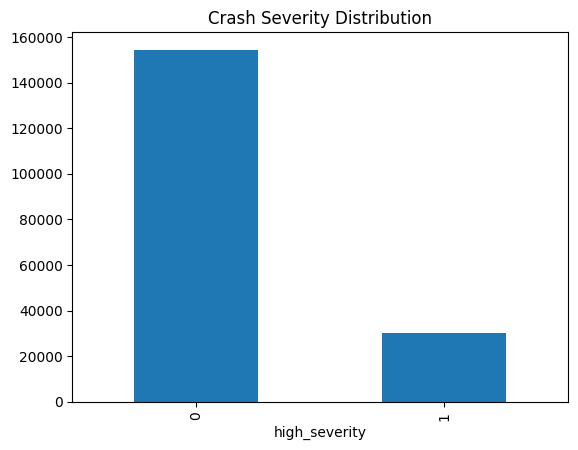

In [8]:
df['high_severity'].value_counts().plot(kind='bar')
plt.title("Crash Severity Distribution")
plt.show()

### Crash Severity Distribution

The distribution of the target variable shows a clear class imbalance, with a significantly higher number of lower-severity crashes compared to high-severity crashes. This imbalance is important to consider during modeling, as it can affect the model’s ability to correctly identify high-severity cases.

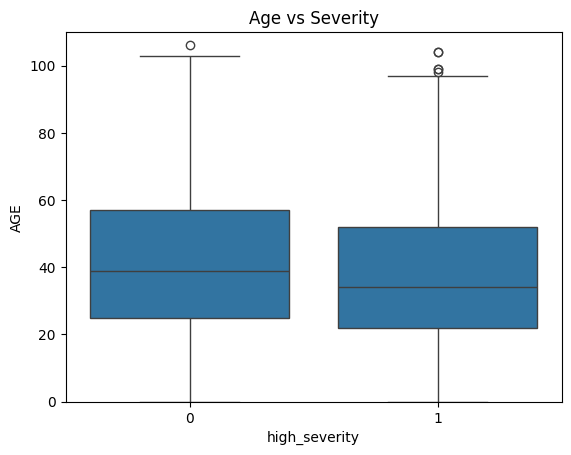

In [9]:
sns.boxplot(x='high_severity', y='AGE', data=df)
plt.title("Age vs Severity")
plt.ylim(0, 110)   # adjust based on your data
plt.show()

### Age vs. Crash Severity

A boxplot was used to examine the relationship between driver age and crash severity. The results indicate that higher-severity crashes tend to involve younger drivers on average. This suggests that age may be an important factor in predicting crash outcomes, potentially reflecting differences in driving experience or risk behavior

### Handling Missing Values

Coded values used in the dataset to represent missing or unknown information (e.g., 8, 9, 99) were replaced with NaN to ensure proper handling during preprocessing and model training.

In [10]:
# ============================================================
# 6. Replace coded missing values
# ============================================================

# FARS often uses numeric codes such as 8, 9, 98, 99, 998, 999 to 
# represent unknown, missing, or not reported values.

missing_codes = [8, 9, 98, 99, 998, 999]
df = df.replace(missing_codes, np.nan)


### Feature Definition

A set of relevant features was selected to represent driver characteristics, vehicle behavior, environmental conditions, and roadway factors. The list was dynamically filtered to include only variables present in the dataset, ensuring compatibility and robustness in the modeling process.

In [11]:
# ============================================================
# 7. Define features
# ============================================================

features = [
    'SPEEDREL',
    'TRAV_SP',
    'AGE',
    'SEX',
    'DRUGS',
    'WEATHER',
    'LGT_COND',
    'VSPD_LIM',
    'FUNC_SYS',
    'HOUR'
]

features = [c for c in features if c in df.columns]

print("Final features used:", features)


Final features used: ['SPEEDREL', 'TRAV_SP', 'AGE', 'SEX', 'DRUGS', 'WEATHER', 'LGT_COND', 'VSPD_LIM', 'FUNC_SYS', 'HOUR']


### Feature and Target Definition

The dataset was split into input features (X) and the target variable (y). Features were further categorized into numerical and categorical variables to support appropriate preprocessing and modeling.

In [12]:
# ============================================================
# 8. Create X and y
# ============================================================

X = df[features].copy()
y = df['high_severity'].copy()

num_cols = [c for c in ['TRAV_SP', 'AGE', 'VSPD_LIM', 'HOUR'] if c in X.columns]
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['TRAV_SP', 'AGE', 'VSPD_LIM', 'HOUR']
Categorical columns: ['SPEEDREL', 'SEX', 'DRUGS', 'WEATHER', 'LGT_COND', 'FUNC_SYS']


In [13]:
# ============================================================
# 9. Ensure categorical columns have consistent type
# ============================================================

for col in cat_cols:
    X[col] = X[col].astype("object")


### Train-Test-Split

The data was split into training (80%) and testing (20%) sets using stratification to preserve the class distribution of the target variable, ensuring a fair and reliable evaluation of model performance.

In [14]:
# ============================================================
# 10. Train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 147786
Testing rows: 36947


### Preprocessing Pipeline

A preprocessing pipeline was created to handle numerical and categorical features separately. Numerical variables were imputed and scaled, while categorical variables were imputed, converted to a consistent format, and one-hot encoded. This ensures clean and consistent data input for model training.

In [15]:
# ============================================================
# 11. Preprocessing pipeline
# ============================================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('to_string', FunctionTransformer(lambda x: x.astype(str))),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


### Logistic Regression Model

A Logistic Regression model was implemented as a baseline using the preprocessing pipeline. The model was trained on the training data and evaluated on the test set using classification metrics and ROC-AUC to assess performance.

In [17]:
# ============================================================
# 12. Model 1: Logistic Regression
# ============================================================

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.89      0.75      0.82     30886
           1       0.30      0.54      0.38      6061

    accuracy                           0.72     36947
   macro avg       0.60      0.64      0.60     36947
weighted avg       0.79      0.72      0.75     36947

ROC-AUC: 0.7075758197196169


### Random Forest Model

A Random Forest model was implemented to capture nonlinear relationships and interactions between features. The model was trained using the preprocessing pipeline and evaluated on the test set using classification metrics and ROC-AUC.

In [18]:
# ============================================================
# 13. Model 2: Random Forest
# ============================================================

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))


Random Forest Results
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     30886
           1       0.87      0.71      0.78      6061

    accuracy                           0.93     36947
   macro avg       0.91      0.84      0.87     36947
weighted avg       0.93      0.93      0.93     36947

ROC-AUC: 0.943509949778538


### Gradient Boosting Model

A Gradient Boosting model was implemented to improve predictive performance by combining multiple weak learners. The model was trained using the preprocessing pipeline and evaluated on the test set using classification metrics and ROC-AUC.

In [19]:
# ============================================================
# 14. Model 3: HistGradientBoostingClassifier
# ============================================================

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting Results")
print(classification_report(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob))


Gradient Boosting Results
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     30886
           1       1.00      0.22      0.36      6061

    accuracy                           0.87     36947
   macro avg       0.93      0.61      0.65     36947
weighted avg       0.89      0.87      0.84     36947

ROC-AUC: 0.7386068831414709


In [20]:
# ============================================================
# 15. Compare models
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

print(model_results)


                  Model   ROC_AUC
0   Logistic Regression  0.707576
1         Random Forest  0.943510
2  HistGradientBoosting  0.738607


### Model Performance Summary

The Random Forest model significantly outperformed the other models, achieving the highest ROC-AUC (0.94), indicating strong predictive ability. Logistic Regression (0.71) and Gradient Boosting (0.74) showed moderate performance, suggesting that nonlinear models are better suited for capturing the complexity of crash severity prediction.

Confusion Matrix:
[[30255   631]
 [ 1772  4289]]


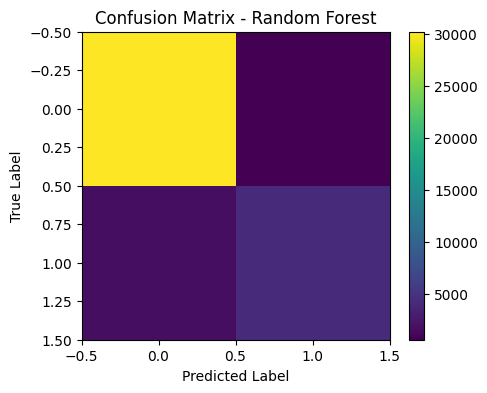

In [21]:
# ============================================================
# 16. Confusion matrix for best model
# Change this to rf_pred, log_pred, or gb_pred depending on best model
# ============================================================

best_pred = rf_pred

cm = confusion_matrix(y_test, best_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()


### Confusion Matrix

The model correctly classified most low-severity and high-severity crashes, with relatively few false positives. However, some high-severity cases were missed, indicating room for improvement in recall for identifying high-risk crashes.

### Cross-Validation

Stratified 5-fold cross-validation was applied to the Random Forest model to evaluate its stability and generalization. ROC-AUC scores across folds were consistent, indicating reliable model performance.

In [22]:
# ============================================================
# 17. Cross-validation for Random Forest
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("Random Forest Cross-Validation ROC-AUC Scores:")
print(cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())


Random Forest Cross-Validation ROC-AUC Scores:
[0.94338613 0.94184457 0.94224325 0.94020486 0.94254952]
Mean ROC-AUC: 0.942045664304923


### Feature Importance

Feature importance was extracted from the Random Forest model to identify the most influential predictors. Encoded feature names were combined with importance scores, and the top features were visualized to highlight key factors driving crash severity predictions.

          Feature  Importance
1             AGE    0.250800
3            HOUR    0.186587
2        VSPD_LIM    0.148679
0         TRAV_SP    0.097921
24    WEATHER_6.0    0.041469
35   FUNC_SYS_1.0    0.025281
16    WEATHER_1.0    0.024647
27   LGT_COND_1.0    0.014700
37   FUNC_SYS_3.0    0.014201
4    SPEEDREL_0.0    0.012297
38   FUNC_SYS_4.0    0.012279
28   LGT_COND_2.0    0.012154
17   WEATHER_10.0    0.011420
15  DRUGS_Unknown    0.011283
7    SPEEDREL_4.0    0.011021
29   LGT_COND_3.0    0.010642
39   FUNC_SYS_5.0    0.009771
20    WEATHER_2.0    0.008929
13      DRUGS_0.0    0.008770
11        SEX_2.0    0.008293


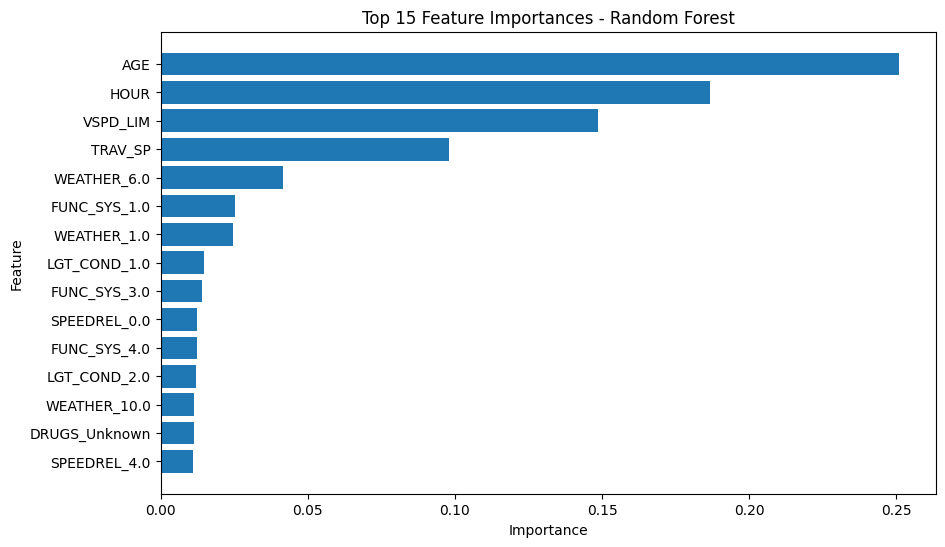

In [23]:
# ============================================================
# 18. Feature importance for Random Forest
# ============================================================

rf_classifier = rf_model.named_steps['classifier']
preprocessor_fitted = rf_model.named_steps['preprocessor']

# Numeric feature names
numeric_features = num_cols

# Categorical feature names from fitted OneHotEncoder
cat_pipeline = preprocessor_fitted.named_transformers_['cat']
onehot = cat_pipeline.named_steps['onehot']

categorical_features = onehot.get_feature_names_out(cat_cols)

# Combine numeric + encoded categorical names
encoded_feature_names = list(numeric_features) + list(categorical_features)

# Build feature importance dataframe
feature_importances = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importances.head(20))

# Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importances.head(15)["Feature"],
    feature_importances.head(15)["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()


### Feature Importance Results

Driver age was the most influential factor in predicting crash severity, followed by time of crash and speed-related variables. Environmental and roadway conditions (weather, lighting, and road type) also contributed to the model, while demographic and drug-related factors had smaller impacts. Overall, the results highlight the importance of driver behavior and driving conditions in determining crash severity.

In [24]:
# ============================================================
# 19. Save final modeling dataset
# ============================================================

final_df = X.copy()
final_df['high_severity'] = y

final_df.to_csv("fars_modeling_dataset.csv", index=False)

print("Saved final modeling dataset as fars_modeling_dataset.csv")


Saved final modeling dataset as fars_modeling_dataset.csv


### Model Tuning

RandomizedSearchCV was used to optimize key hyperparameters of the Random Forest model. A limited search space was explored using cross-validation and F1-score as the evaluation metric to improve model performance efficiently.

In [25]:
# ============================================================
# 20. Model Tuning
# ============================================================

param_dist = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
}

random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=5,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print(random_search.best_params_)

{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__max_depth': None}


In [26]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96     30886
           1       0.87      0.71      0.78      6061

    accuracy                           0.94     36947
   macro avg       0.91      0.84      0.87     36947
weighted avg       0.93      0.94      0.93     36947



### Tuned Model Results

Hyperparameter tuning selected a Random Forest model with 200 trees, no maximum depth restriction, and a minimum sample split of 2. The tuned model achieved an overall accuracy of 94%, with strong performance in identifying high-severity crashes (precision: 0.87, recall: 0.71, F1-score: 0.78).

### Comparison to Previous Model

The tuned model shows minimal improvement over the original:
- Accuracy increased slightly
- Precision and recall for high-severity crashes remain nearly the same
- F1-score is essentially unchanged

This indicates the original model was already well-optimized, and additional tuning provided only marginal gains.

### Interpretation

The model maintains strong ability to correctly identify high-severity crashes while keeping false positives low. However, recall remains moderate, meaning some high-risk crashes are still missed.

### Final Takeaway

Tuning confirmed the robustness of the Random Forest model, but did not significantly improve performance, suggesting that further gains may require additional features or alternative modeling approaches rather than parameter adjustments alone.